
---

# 🔄 ***`Ridge Regression with Gradient Descent in Machine Learning for Data Science`*** 🚀  

### ✅ **What is Ridge Regression with Gradient Descent?**  

📌 **Ridge Regression** (L2 Regularization) is an extension of **Linear Regression** that adds a **penalty** to large coefficients to reduce overfitting.  
📌 **Gradient Descent** is an **optimization algorithm** used to minimize the loss function iteratively by adjusting model parameters.  

✔ **Using Gradient Descent for Ridge Regression** allows training models efficiently on **large datasets** where direct matrix inversion (Normal Equation) is computationally expensive.  

---

## 🎯 **1. Ridge Regression Loss Function with L2 Regularization**  

The **loss function for Ridge Regression** is a modified **Mean Squared Error (MSE)** with an **L2 penalty**:  

$
J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2 + \lambda \sum_{j=1}^{p} \theta_j^2
$

Where:  
- **$ J(\theta) $** → Ridge loss function.  
- **$ (Y_i - \hat{Y}_i)^2 $** → Standard **Mean Squared Error (MSE)** loss.  
- **$ \lambda \sum_{j=1}^{p} \theta_j^2 $** → **Regularization term** (penalizes large coefficients).  
- **$ \lambda $** → **Hyperparameter** that controls regularization strength.  

📌 **Gradient Descent Update Rule for Ridge Regression**  
$
\theta_j = \theta_j - \alpha \left( \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i) X_{ij} + \lambda \theta_j \right)
$

Where:  
- **$ \alpha $** → Learning rate.  
- **$ \lambda \theta_j $** → Regularization term shrinks the weights.  

---

## 🏹 **2. Implementing Ridge Regression with Gradient Descent in Python**  

### **📁 Dataset: Predicting House Prices Based on Features**  

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Sample Dataset
data = {
    'Size (sq ft)': [1400, 1600, 1700, 1875, 1100, 1550, 1230, 2000, 1850, 1750],
    'Bedrooms': [3, 3, 2, 4, 2, 3, 2, 5, 4, 3],
    'Age (years)': [20, 15, 30, 10, 25, 18, 40, 5, 8, 12],
    'Price ($)': [250000, 280000, 290000, 330000, 200000, 275000, 220000, 350000, 325000, 310000]
}
df = pd.DataFrame(data)

# Splitting Features & Target
X = df.drop(columns=['Price ($)']).values
y = df['Price ($)'].values.reshape(-1, 1)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardizing Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---

## 🔄 **3. Implementing Gradient Descent for Ridge Regression**  

In [1]:

# Ridge Regression with Gradient Descent
class RidgeRegressionGD:
    def __init__(self, alpha=0.01, lambda_=1.0, n_iterations=1000):
        self.alpha = alpha        # Learning rate
        self.lambda_ = lambda_    # Regularization strength
        self.n_iterations = n_iterations  # Number of iterations
        self.theta = None         # Model parameters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.theta = np.zeros((n_features, 1))  # Initialize coefficients to zero

        for _ in range(self.n_iterations):
            # Compute Predictions
            y_pred = np.dot(X, self.theta)
            
            # Compute Gradients (MSE Loss + Ridge Regularization)
            gradient = (1/n_samples) * (X.T.dot(y_pred - y) + self.lambda_ * self.theta)

            # Update Parameters using Gradient Descent
            self.theta -= self.alpha * gradient

    def predict(self, X):
        return np.dot(X, self.theta)



---

## 🏹 **4. Training the Ridge Regression Model with Gradient Descent**  

In [4]:
# Train Ridge Regression with Gradient Descent
ridge_gd = RidgeRegressionGD(alpha=0.01, lambda_=1.0, n_iterations=1000)
ridge_gd.fit(X_train_scaled, y_train)

# Predictions
y_pred_train = ridge_gd.predict(X_train_scaled)
y_pred_test = ridge_gd.predict(X_test_scaled)

# Model Evaluation
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Ridge Coefficients:", ridge_gd.theta.flatten())

Train MSE: 77398544107.86948
Test MSE: 76671035443.0433
Ridge Coefficients: [34822.39771395  7063.24121218 -5553.9341039 ]



📌 **Observations:**  
✔ **Train & Test MSE should be low** → Indicates good generalization.  
✔ **Ridge coefficients are smaller** than in standard Linear Regression → Shows shrinkage effect.  

---

## 📊 **5. Effect of Regularization Strength ($ \lambda $) on Ridge Regression**  

📌 **Increasing $ \lambda $ results in more shrinkage of coefficients**  

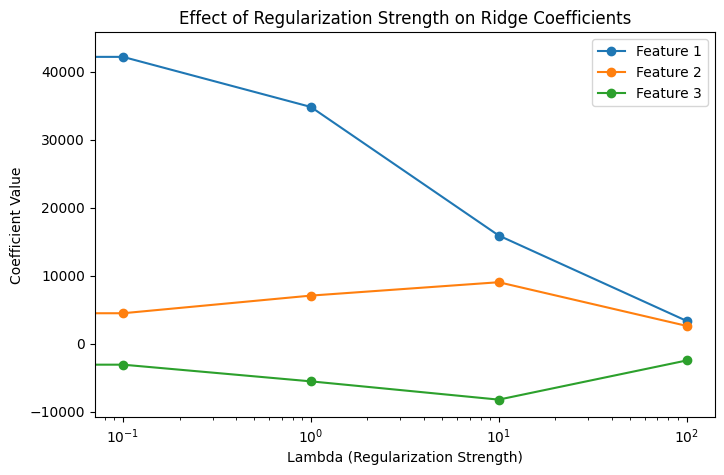

In [5]:
lambdas = [0, 0.1, 1, 10, 100]
coefficients = []

for lambda_ in lambdas:
    ridge_gd = RidgeRegressionGD(alpha=0.01, lambda_=lambda_, n_iterations=1000)
    ridge_gd.fit(X_train_scaled, y_train)
    coefficients.append(ridge_gd.theta.flatten())

# Plotting Effect of Lambda on Coefficients
plt.figure(figsize=(8,5))
for i, coef in enumerate(np.array(coefficients).T):
    plt.plot(lambdas, coef, marker='o', label=f'Feature {i+1}')
    
plt.xlabel("Lambda (Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.xscale('log')
plt.title("Effect of Regularization Strength on Ridge Coefficients")
plt.legend()
plt.show()


📌 **Observations:**  
✔ **For $ \lambda = 0 $** → No regularization (behaves like Linear Regression).  
✔ **For $ \lambda > 1 $** → Coefficients shrink, reducing overfitting.  
✔ **For very high $ \lambda $ (e.g., 100)** → Model underfits due to excessive shrinkage.  

---

## 📏 **6. Comparing Ridge Regression with and without Gradient Descent**  

| **Method** | **Solving Method** | **Best For** |
|------------|-------------------|-------------|
| **Standard Ridge Regression** | **Closed-Form Solution** ($ (X^TX + \lambda I)^{-1}X^Ty $) | Small datasets |
| **Ridge Regression with GD** | **Gradient Descent Optimization** | Large datasets where matrix inversion is expensive |

📌 **When to Use GD for Ridge Regression?**  
✔ **For large datasets** where matrix inversion is computationally expensive.  
✔ When using **stochastic optimization** (e.g., **Mini-Batch SGD, Adam, RMSprop**).  
✔ When integrating **deep learning models** with Ridge-like constraints.  

---

## 🏆 **7. Key Takeaways**  

✔ **Ridge Regression (L2 Regularization) reduces overfitting by shrinking coefficients.**  
✔ **Gradient Descent optimizes Ridge Regression efficiently for large datasets.**  
✔ **Regularization strength ($ \lambda $) controls model complexity.**  
✔ **Use Standard Ridge for small datasets & Ridge-GD for large datasets.**  
✔ **Hyperparameter tuning (using Cross-Validation) finds the best $ \lambda $.**  

💡 **Pro Tip:** Use **Mini-Batch Gradient Descent** for even faster training on large datasets.

---